# Error Analysis

The [previous notebooks](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/04_neural_multimodal_classifier.ipynb) focused on building, training, and evaluating multimodal classifiers using quantitative metrics such as accuracy, precision, recall, and F1-score. While these metrics provide an overall measure of performance, they do not explain **why** the models succeed or fail on individual image-caption pairs.

The goal of this notebook is to analyze the predictions made by the trained neural models, identify common error patterns, and better understand their strengths and limitations. In particular, the notebook compares the frozen ResNet18 and fine-tuned ResNet18 classifiers by examining correctly and incorrectly classified examples.

The insights obtained from this analysis will help explain the observed evaluation metrics and guide potential improvements for future multimodal models.

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [20]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.config import (
    DATASET_NAME,
    RANDOM_SEED,
    DEVICE,
    MODELS_DIR,
    RESULTS_DIR,
    DOWNLOADS_DIR,
    MAX_CAPTION_LENGTH,
    EMBEDDING_DIM,
    IMAGE_FEATURE_DIM,
    HIDDEN_DIM,
    DROPOUT,
    BATCH_SIZE,
)

from src.data.loaders import load_flickr30k_splits
from src.data.preparation import prepare_binary_dataset
from src.text.tokenization import build_vocab
from src.features.image_features import (
    get_resnet18_feature_extractor,
    get_resnet18_transforms,
    extract_image_features,
)
from src.datasets.embedding_dataset import Flickr30kEmbeddingDataset
from src.datasets.multimodal_dataset import Flickr30kBinaryDataset
from src.models.multimodal_embedding_classifier import NeuralMultimodalEmbeddingClassifier
from src.models.multimodal_classifier import NeuralMultimodalClassifier

In [3]:
print(f"Using device: {DEVICE}")

Using device: mps


## Load Dataset and Validation Pairs

In [15]:
# Load the dataset
train_data, val_data, test_data = load_flickr30k_splits(DATASET_NAME)

# Generate the binary pairs
train_pairs = prepare_binary_dataset(train_data, seed=RANDOM_SEED)
val_pairs = prepare_binary_dataset(val_data, seed=RANDOM_SEED)

train_pairs.shape, val_pairs.shape

((290000, 4), (10140, 4))

In [16]:
# Build the vocabular
vocab = build_vocab(
    train_pairs["caption"],
    min_freq=1,
)

len(vocab)

17714

## Load Saved Models

The frozen model expects precomputed image embeddings, while the fine-tuned model expects raw image tensors. Therefore, separate datasets and prediction pipelines will be used for each model.

In [6]:
frozen_model = NeuralMultimodalEmbeddingClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    image_feature_dim=IMAGE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
).to(DEVICE)

frozen_model.load_state_dict(
    torch.load(
        MODELS_DIR / "frozen_resnet18_embedding_classifier.pt",
        map_location=DEVICE,
    )
)

frozen_model.eval()

NeuralMultimodalEmbeddingClassifier(
  (text_embedding): Embedding(17714, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=640, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [12]:
finetuned_model = NeuralMultimodalClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    image_feature_dim=IMAGE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_image_encoder=True,
    unfreeze_layer4=True,
).to(DEVICE)

finetuned_model.load_state_dict(
    torch.load(
        DOWNLOADS_DIR / "finetuned_resnet18_classifier.pt",
        map_location=DEVICE,
    )
)

finetuned_model.eval()

NeuralMultimodalClassifier(
  (image_encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.

## Prepare Evaluation Dataset

The trained models are evaluated on the validation dataset used during model development. To ensure a fair comparison, the same image-caption pairs and preprocessing pipeline are used for both the frozen and fine-tuned models.

The evaluation dataset serves as a common input for generating predictions and analyzing model behavior.

In [17]:
val_pairs.shape, len(vocab)

((10140, 4), 17714)

## Prepare Evaluation DataLoaders

Goal:

Frozen model     → val_embedding_loader

Fine-tuned model → val_loader

Since the frozen model needs image embeddings, first extract validation image features

In [18]:
image_feature_extractor = get_resnet18_feature_extractor(DEVICE)
image_transform = get_resnet18_transforms()

val_image_features = extract_image_features(
    val_data,
    image_feature_extractor,
    image_transform,
    DEVICE,
)

100%|██████████| 1014/1014 [00:12<00:00, 79.16it/s]


Then create both validation datasets/loaders

In [21]:
from torch.utils.data import DataLoader

val_embedding_dataset = Flickr30kEmbeddingDataset(
    pairs=val_pairs,
    image_features=val_image_features,
    vocab=vocab,
    max_length=MAX_CAPTION_LENGTH,
)

val_raw_dataset = Flickr30kBinaryDataset(
    pairs=val_pairs,
    hf_dataset=val_data,
    vocab=vocab,
    transform=image_transform,
    max_length=MAX_CAPTION_LENGTH,
)

val_embedding_loader = DataLoader(
    val_embedding_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

val_raw_loader = DataLoader(
    val_raw_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [22]:
# verify
embedding_batch = next(iter(val_embedding_loader))
raw_batch = next(iter(val_raw_loader))

print("Frozen model batch:")
print(embedding_batch[0].shape, embedding_batch[1].shape, embedding_batch[2].shape)

print("Fine-tuned model batch:")
print(raw_batch[0].shape, raw_batch[1].shape, raw_batch[2].shape)

Frozen model batch:
torch.Size([32, 512]) torch.Size([32, 32]) torch.Size([32])
Fine-tuned model batch:
torch.Size([32, 3, 224, 224]) torch.Size([32, 32]) torch.Size([32])


In [27]:
len(val_raw_loader), len(val_raw_dataset) / BATCH_SIZE

(317, 316.875)

## Generate Predictions

Predictions are generated for both the frozen ResNet18 and fine-tuned ResNet18 models using the validation dataset. In addition to the predicted class labels, the predicted probabilities are also stored to enable confidence analysis and experimentation with different classification thresholds.

The predictions from both models are combined into a single DataFrame, which serves as the foundation for the subsequent error analysis and model comparison.

In [23]:
from src.evaluation.predict import predict_binary_classifier

frozen_predictions = predict_binary_classifier(
    model=frozen_model,
    dataloader=val_embedding_loader,
    device=DEVICE,
    threshold=0.5,
)

finetuned_predictions = predict_binary_classifier(
    model=finetuned_model,
    dataloader=val_raw_loader,
    device=DEVICE,
    threshold=0.5,
)

Predicting: 100%|██████████| 317/317 [00:50<00:00,  6.29it/s]


In [28]:
analysis_df = val_pairs.copy()

analysis_df["frozen_prob"] = frozen_predictions["probabilities"]
analysis_df["frozen_pred"] = frozen_predictions["predictions"]

analysis_df["finetuned_prob"] = finetuned_predictions["probabilities"]
analysis_df["finetuned_pred"] = finetuned_predictions["predictions"]

analysis_df.head()

,img_id,filename,caption,label,frozen_prob,frozen_pred,finetuned_prob,finetuned_pred
0,6767,2563482243.jpg,Worker being lifted up in a cherry picker to p...,1,0.770976,1,0.841036,1
1,12984,3353950389.jpg,The people are gathered at a bar.,1,0.740727,1,0.891778,1
2,1532,144328407.jpg,Five young men pose on the steps.,0,0.029229,0,0.001494,0
3,6586,2541104331.jpg,A man reads the paper while waiting for the su...,0,0.001597,0,0.000009,0
4,8405,2777021428.jpg,A little boy in blue and wearing a backwards c...,1,0.740727,1,0.699568,1


## Overall Comparison

Before analyzing individual prediction errors, it is useful to compare the overall performance of both models on the validation dataset. This provides a high-level view of their classification behavior and helps explain the differences observed during training.

The following comparison summarizes the main evaluation metrics for both neural models.

In [36]:
frozen_metrics = pd.read_csv(
    RESULTS_DIR / "frozen_resnet18_metrics.csv"
)

finetuned_metrics = pd.read_csv(
    RESULTS_DIR / "finetuned_resnet18_metrics.csv"
)

comparison_df = pd.concat(
    [frozen_metrics, finetuned_metrics],
    ignore_index=True,
)

comparison_df["training_time_minutes"] = (
    comparison_df["training_time_seconds"] / 60
).round(1)

comparison_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "training_time_minutes",
    ]
]

,model,accuracy,precision,recall,f1,training_time_minutes
0,Frozen ResNet18 Neural Classifier,0.739842,0.667171,0.957199,0.786293,11.1
1,Finetune ResNet18 Neural Classifier,0.761440,0.754659,0.774753,0.764574,166.3


### Observation

The two neural models exhibit different performance characteristics. The frozen ResNet18 model achieves the highest F1-score, primarily due to its very high recall, indicating that it successfully identifies most positive image-caption pairs. However, this comes at the cost of lower precision, meaning it produces more false positive predictions.

In contrast, the fine-tuned ResNet18 model achieves higher validation accuracy and substantially improves precision while maintaining a more balanced trade-off between precision and recall. These improvements, however, require significantly longer training time, illustrating the trade-off between predictive performance and computational efficiency.

## Prediction Agreement

To better understand the differences between the two neural models, it is useful to compare their predictions on the same validation examples. Rather than analyzing each model independently, this comparison identifies cases where both models are correct, where only one model makes the correct prediction, and where both models fail.

This analysis provides a high-level overview of how the models complement each other and helps identify examples that are particularly challenging for image-text matching.

In [37]:
# Determine correctness
analysis_df["frozen_correct"] = (
    analysis_df["frozen_pred"] == analysis_df["label"]
)

analysis_df["finetuned_correct"] = (
    analysis_df["finetuned_pred"] == analysis_df["label"]
)

In [38]:
# Assign agreement category
def prediction_category(row):
    if row["frozen_correct"] and row["finetuned_correct"]:
        return "Both correct"

    if row["frozen_correct"] and not row["finetuned_correct"]:
        return "Frozen only"

    if not row["frozen_correct"] and row["finetuned_correct"]:
        return "Fine-tuned only"

    return "Both wrong"


analysis_df["prediction_category"] = (
    analysis_df.apply(prediction_category, axis=1)
)

In [39]:
# Count examples
agreement_df = (
    analysis_df["prediction_category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

agreement_df["percentage"] = (
    agreement_df["count"] / len(analysis_df) * 100
).round(2)

agreement_df

,category,count,percentage
0,Both correct,6197,61.11
1,Fine-tuned only,1524,15.03
2,Frozen only,1305,12.87
3,Both wrong,1114,10.99


### Observation

The two models produce identical predictions for the majority of the validation examples, with more than 60% classified correctly by both models and approximately 11% misclassified by both. This indicates that many image-caption pairs are either consistently easy or consistently difficult regardless of the transfer learning strategy.

The remaining examples highlight the differences between the models. The fine-tuned model correctly classifies a larger proportion of examples that the frozen model misclassifies, which explains its higher validation accuracy. Conversely, the frozen model correctly identifies some additional positive pairs, contributing to its higher recall and overall F1-score. These results suggest that the two models learn different decision boundaries rather than simply differing in overall performance.

## Threshold Sensitivity Analysis

The default classification threshold of 0.5 is commonly used for binary classifiers, but it is not necessarily the optimal choice for every model or task. Adjusting the decision threshold changes the trade-off between precision and recall, which can significantly affect the overall model performance.

This section evaluates both neural models using several probability thresholds to investigate how the classification behavior changes and whether a different threshold can improve the evaluation metrics.

In [40]:
from src.evaluation.threshold_analysis import evaluate_thresholds

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

frozen_threshold_results = evaluate_thresholds(
    probabilities=analysis_df["frozen_prob"].to_numpy(),
    labels=analysis_df["label"].to_numpy(),
    thresholds=thresholds,
)

finetuned_threshold_results = evaluate_thresholds(
    probabilities=analysis_df["finetuned_prob"].to_numpy(),
    labels=analysis_df["label"].to_numpy(),
    thresholds=thresholds,
)

frozen_threshold_results["model"] = "Frozen ResNet18"
finetuned_threshold_results["model"] = "Fine-tuned ResNet18"

threshold_results = pd.concat(
    [frozen_threshold_results, finetuned_threshold_results],
    ignore_index=True,
)

threshold_results

,threshold,accuracy,precision,recall,f1,model
0,0.3,0.673767,0.606170,0.992110,0.752543,Frozen ResNet18
1,0.4,0.709172,0.635909,0.978698,0.770916,Frozen ResNet18
2,0.5,0.739842,0.667171,0.957199,0.786293,Frozen ResNet18
3,0.6,0.761736,0.702905,0.906706,0.791904,Frozen ResNet18
4,0.7,0.751775,0.746191,0.763116,0.754559,Frozen ResNet18
5,0.8,0.533037,0.903614,0.073964,0.136737,Frozen ResNet18
6,0.3,0.754241,0.707769,0.866075,0.778960,Fine-tuned ResNet18
7,0.4,0.759467,0.731317,0.820316,0.773264,Fine-tuned ResNet18
8,0.5,0.761440,0.754659,0.774753,0.764574,Fine-tuned ResNet18
9,0.6,0.758383,0.783182,0.714596,0.747318,Fine-tuned ResNet18


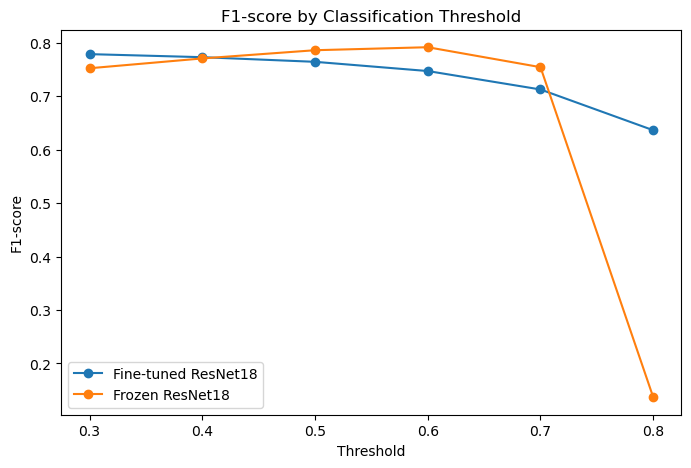

In [41]:
plt.figure(figsize=(8, 5))

for model_name, model_df in threshold_results.groupby("model"):
    plt.plot(
        model_df["threshold"],
        model_df["f1"],
        marker="o",
        label=model_name,
    )

plt.title("F1-score by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend()
plt.show()

### Observation

The threshold sensitivity analysis shows that the default classification threshold of 0.5 is not optimal for either model. The frozen ResNet18 model achieves its highest F1-score at a threshold of 0.6, indicating that a slightly more conservative decision boundary improves the balance between precision and recall. In contrast, the fine-tuned model performs best at a lower threshold of 0.3, suggesting that it produces more conservative probability estimates for positive image-caption pairs.

These results demonstrate that the choice of classification threshold has a measurable impact on model performance and should be considered when evaluating binary classifiers. Nevertheless, even after threshold optimization, the frozen ResNet18 model retains the highest overall F1-score, while the fine-tuned model continues to provide higher accuracy and a more balanced precision–recall trade-off.


## Prediction Probability Distribution

The previous threshold analysis demonstrated that the optimal classification threshold differs between the two neural models. To better understand this behavior, the predicted probability distributions are visualized separately for positive and negative image-caption pairs.

Well-separated probability distributions indicate that the model assigns high confidence to correct predictions, whereas overlapping distributions suggest greater uncertainty and a higher likelihood of misclassification.

In [42]:
plot_df = pd.DataFrame({
    "label": analysis_df["label"],
    "Frozen ResNet18": analysis_df["frozen_prob"],
    "Fine-tuned ResNet18": analysis_df["finetuned_prob"],
})

plot_df = plot_df.melt(
    id_vars="label",
    var_name="model",
    value_name="probability",
)

plot_df.head()

,label,model,probability
0,1,Frozen ResNet18,0.770976
1,1,Frozen ResNet18,0.740727
2,0,Frozen ResNet18,0.029229
3,0,Frozen ResNet18,0.001597
4,1,Frozen ResNet18,0.740727


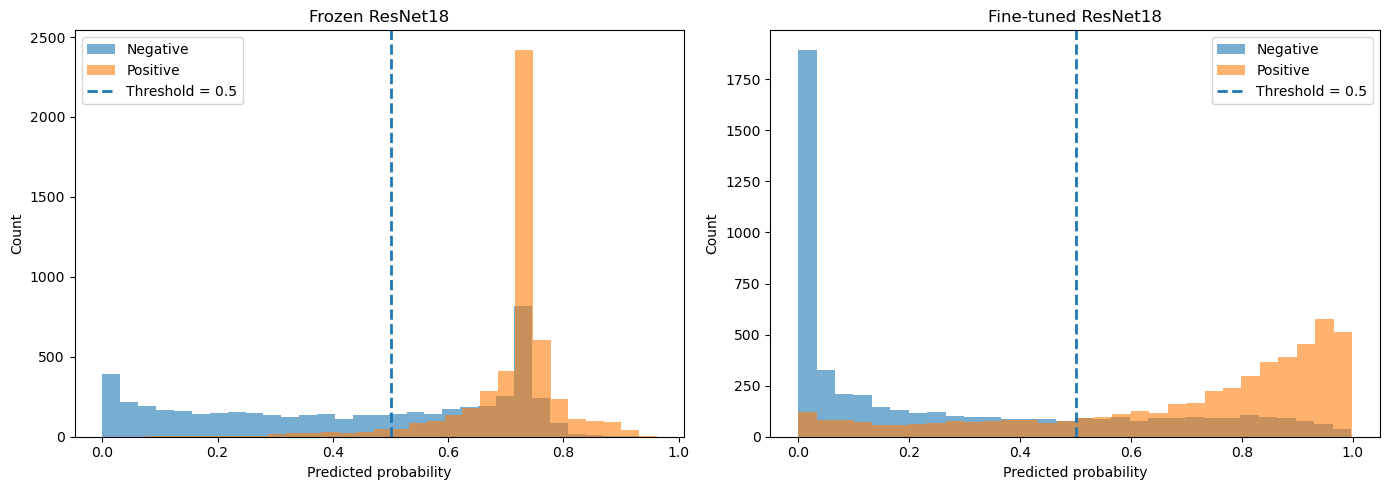

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(
    axes,
    ["Frozen ResNet18", "Fine-tuned ResNet18"],
):

    positive = plot_df[
        (plot_df["model"] == model_name)
        & (plot_df["label"] == 1)
    ]

    negative = plot_df[
        (plot_df["model"] == model_name)
        & (plot_df["label"] == 0)
    ]

    ax.hist(
        negative["probability"],
        bins=30,
        alpha=0.6,
        label="Negative",
    )

    ax.hist(
        positive["probability"],
        bins=30,
        alpha=0.6,
        label="Positive",
    )

    ax.axvline(
        0.5,
        linestyle="--",
        linewidth=2,
        label="Threshold = 0.5",
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [47]:
analysis_df[
    [
        "frozen_prob",
        "finetuned_prob",
    ]
].describe().round(2)

,frozen_prob,finetuned_prob
count,10140.00,10140.00
mean,0.58,0.48
std,0.24,0.36
min,0.00,0.00
25%,0.44,0.08
50%,0.70,0.52
75%,0.74,0.84
max,0.96,1.00


### Observation

The probability distributions reveal clear differences in the confidence of the two models. The frozen ResNet18 model generally assigns higher probabilities, including to many negative image-caption pairs, which explains its very high recall and lower precision. Increasing the decision threshold therefore improves its overall F1-score by reducing false positive predictions.

In contrast, the fine-tuned model produces better-separated probability distributions, with most negative examples assigned low probabilities and most positive examples assigned high probabilities. This results in higher precision and accuracy, although the model is more conservative when predicting positive matches, leading to a lower recall and a slightly lower overall F1-score.

## Fine-tuned Only Predictions

The examples in this section were correctly classified by the fine-tuned ResNet18 model but misclassified by the frozen ResNet18 model. These cases highlight situations where adapting the high-level visual features improves the model's ability to distinguish between matching and non-matching image-caption pairs.

Analyzing these examples helps identify the types of visual or semantic relationships that benefit most from fine-tuning.

Examples correctly classified only by the fine-tuned model


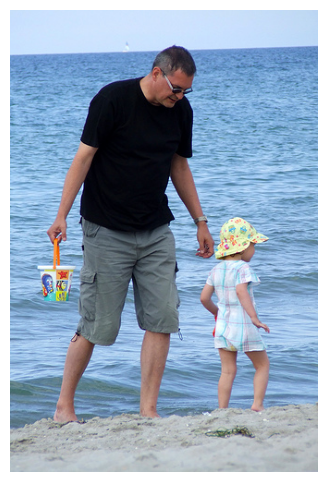

Filename: 3730011219.jpg
Caption: A little girl is smiling, while running outside.
Ground truth: Negative pair
Frozen model: Positive (0.612)
Fine-tuned model: Negative (0.179)
Category: Fine-tuned only
--------------------------------------------------------------------------------


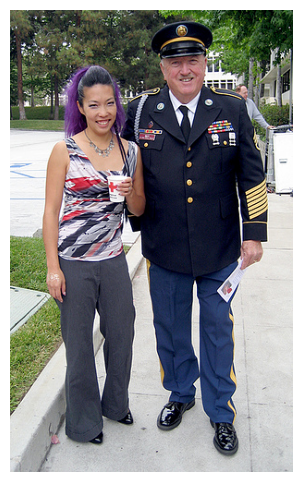

Filename: 3569420080.jpg
Caption: A man in a white shirt working on computer with a help from another man.
Ground truth: Negative pair
Frozen model: Positive (0.641)
Fine-tuned model: Negative (0.115)
Category: Fine-tuned only
--------------------------------------------------------------------------------


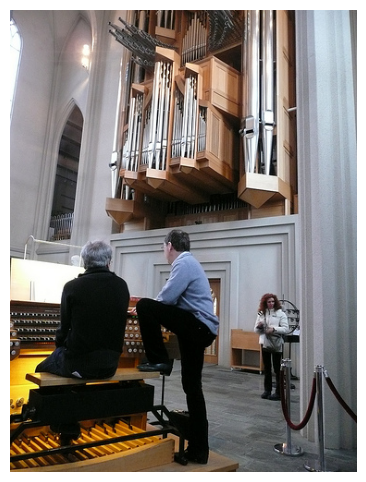

Filename: 2319963351.jpg
Caption: 4 kids sit on a ledge and converse.
Ground truth: Negative pair
Frozen model: Positive (0.753)
Fine-tuned model: Negative (0.009)
Category: Fine-tuned only
--------------------------------------------------------------------------------


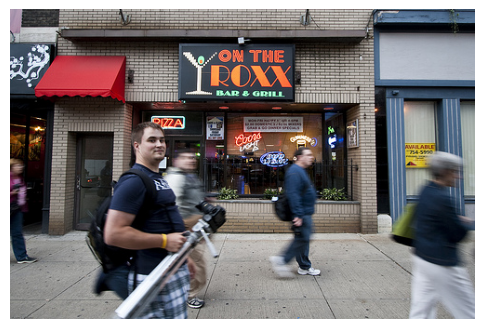

Filename: 3736180463.jpg
Caption: An innertube is being worked on a bicycle by a male and female.
Ground truth: Negative pair
Frozen model: Positive (0.612)
Fine-tuned model: Negative (0.489)
Category: Fine-tuned only
--------------------------------------------------------------------------------


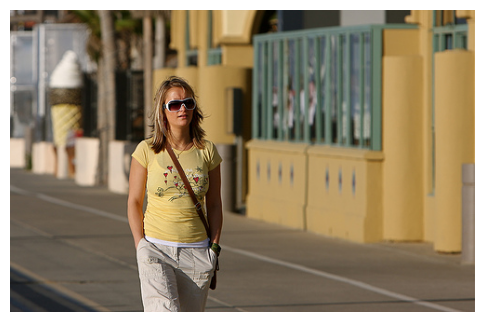

Filename: 3106857210.jpg
Caption: A bald man with a beard holding a shaving device on a beach.
Ground truth: Negative pair
Frozen model: Positive (0.741)
Fine-tuned model: Negative (0.170)
Category: Fine-tuned only
--------------------------------------------------------------------------------


In [50]:
from src.visualization.predictions import show_prediction_examples

show_prediction_examples(
    dataframe=analysis_df,
    hf_dataset=val_data,
    category="Fine-tuned only",
    n=5,
    random_state=RANDOM_SEED,
    title="Examples correctly classified only by the fine-tuned model",
)

In [54]:
fine_tuned_only = analysis_df[
    analysis_df["prediction_category"] == "Fine-tuned only"
]

fine_tuned_only["label"].value_counts(), fine_tuned_only["label"].value_counts(normalize=True).mul(100).round(1)

(label
 0    1434
 1      90
 Name: count, dtype: int64,
 label
 0    94.1
 1     5.9
 Name: proportion, dtype: float64)

### Observation

The vast majority of examples correctly classified only by the fine-tuned model are negative image-caption pairs, confirming that the frozen ResNet18 model has a stronger tendency to predict positive matches. In contrast, the fine-tuned model is more selective and better at rejecting incorrect image-caption pairs, which explains its higher precision.

Some mismatches are visually obvious, where the caption describes completely different objects, people, or scenes. Other cases are more subtle because the image and caption share general semantic concepts, such as similar people, actions, or environments, despite not representing the same event. These examples suggest that fine-tuning improves the model's ability to distinguish true semantic correspondence from superficial visual similarity.


## Frozen Only Predictions

This section examines examples that were correctly classified by the frozen ResNet18 model but misclassified by the fine-tuned model. These cases highlight situations where the pretrained visual representations generalize better than the adapted representations learned during fine-tuning.

By comparing these examples with the previous section, we can better understand the trade-off between achieving higher recall and reducing false positive predictions.

In [56]:
frozen_only = analysis_df[
    analysis_df["prediction_category"] == "Frozen only"
]

frozen_only["label"].value_counts()

label
1    1015
0     290
Name: count, dtype: int64

Examples correctly classified only by the frozen model


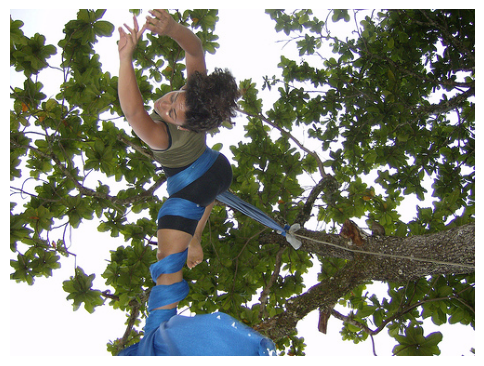

Filename: 347186933.jpg
Caption: Woman hangs on tree limb.
Ground truth: Positive match
Frozen model: Positive (0.682)
Fine-tuned model: Negative (0.144)
Category: Frozen only
--------------------------------------------------------------------------------


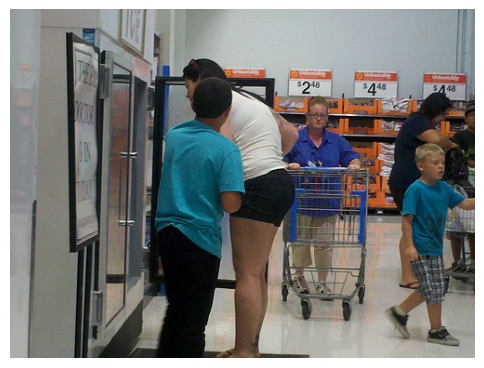

Filename: 6274309052.jpg
Caption: A woman in a white shirt looking in a freezer with Walmart shelves in the background as well as other people in the background.
Ground truth: Positive match
Frozen model: Positive (0.741)
Fine-tuned model: Negative (0.175)
Category: Frozen only
--------------------------------------------------------------------------------


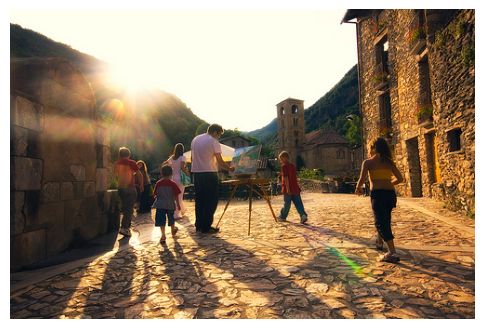

Filename: 2761119252.jpg
Caption: A man paints on an easel as people walk by.
Ground truth: Positive match
Frozen model: Positive (0.739)
Fine-tuned model: Negative (0.367)
Category: Frozen only
--------------------------------------------------------------------------------


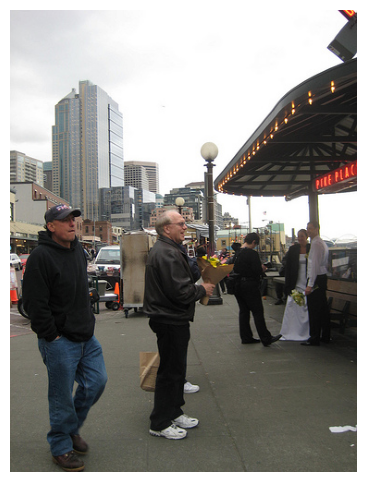

Filename: 3393274529.jpg
Caption: Two men are standing near Pike Place Market while a couple in the background takes a wedding picture.
Ground truth: Positive match
Frozen model: Positive (0.646)
Fine-tuned model: Negative (0.435)
Category: Frozen only
--------------------------------------------------------------------------------


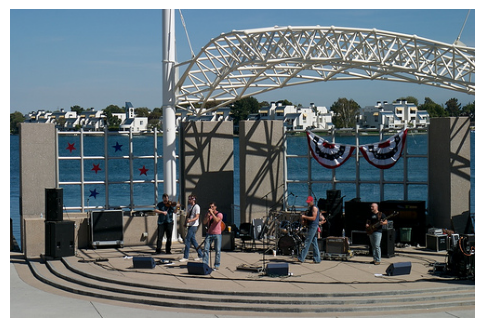

Filename: 2224524855.jpg
Caption: A group of young men clowning around while enjoying a beverage.
Ground truth: Negative pair
Frozen model: Negative (0.484)
Fine-tuned model: Positive (0.850)
Category: Frozen only
--------------------------------------------------------------------------------


In [55]:
show_prediction_examples(
    dataframe=analysis_df,
    hf_dataset=val_data,
    category="Frozen only",
    n=5,
    random_state=RANDOM_SEED,
    title="Examples correctly classified only by the frozen model",
)

### Observation

Most examples correctly classified only by the frozen ResNet18 model are positive image-caption pairs, indicating that the frozen model is better at recovering true matches. These examples suggest that the fine-tuned model occasionally becomes too conservative, assigning low confidence to valid image-caption pairs and thereby reducing recall.

At the same time, a smaller number of negative pairs are correctly rejected only by the frozen model, demonstrating that neither model consistently outperforms the other on every example. Overall, these results reinforce the complementary strengths of the two approaches: the frozen model favors higher recall, while the fine-tuned model places greater emphasis on avoiding false positive predictions.


## Both Wrong Predictions

The final category contains image-caption pairs that were misclassified by both neural models. These examples represent the most challenging cases in the validation set and reveal limitations that are shared by both transfer learning strategies.

Analyzing these failures helps identify common sources of ambiguity in the image-text matching task and provides insight into potential directions for future model improvements.

In [57]:
both_wrong = analysis_df[
    analysis_df["prediction_category"] == "Both wrong"
]

both_wrong["label"].value_counts()

label
0    987
1    127
Name: count, dtype: int64

Examples misclassified by both models


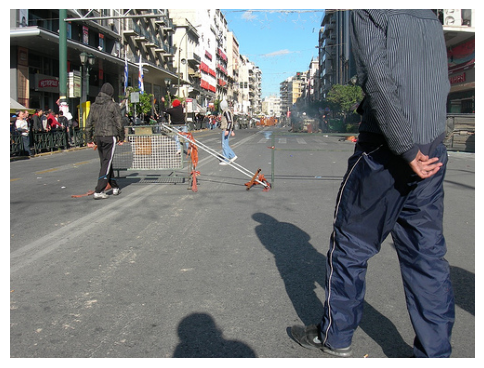

Filename: 3093744301.jpg
Caption: A young man is walking close to the sea.
Ground truth: Negative pair
Frozen model: Positive (0.722)
Fine-tuned model: Positive (0.755)
Category: Both wrong
--------------------------------------------------------------------------------


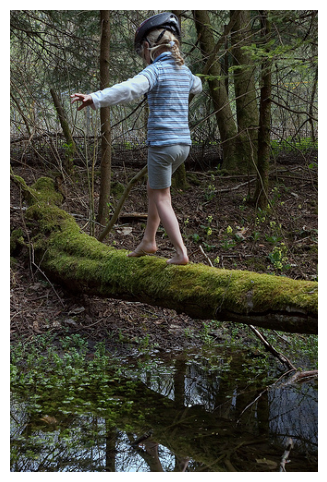

Filename: 3473635435.jpg
Caption: Two small children, a girl and a boy, dressed in white on a state posing in ballet poses.
Ground truth: Negative pair
Frozen model: Positive (0.503)
Fine-tuned model: Positive (0.782)
Category: Both wrong
--------------------------------------------------------------------------------


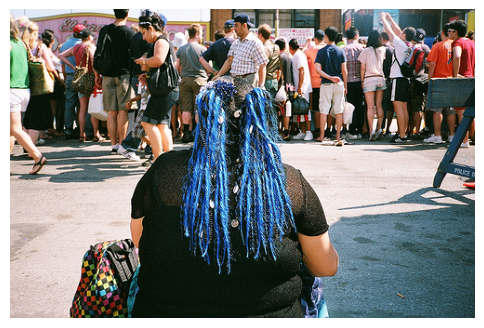

Filename: 4725325505.jpg
Caption: A mariachi band plays a song on the sidewalk.
Ground truth: Negative pair
Frozen model: Positive (0.741)
Fine-tuned model: Positive (0.916)
Category: Both wrong
--------------------------------------------------------------------------------


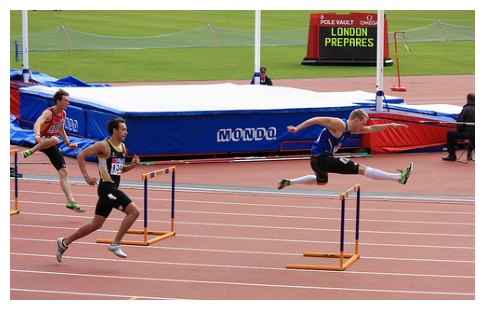

Filename: 7149253081.jpg
Caption: A young boy throws a big rock into a body of water.
Ground truth: Negative pair
Frozen model: Positive (0.752)
Fine-tuned model: Positive (0.541)
Category: Both wrong
--------------------------------------------------------------------------------


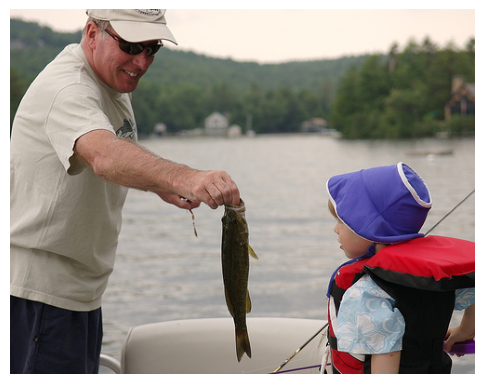

Filename: 566384456.jpg
Caption: A little girl donates to the Salvation Army near a storefront with white, plastic containers.
Ground truth: Negative pair
Frozen model: Positive (0.651)
Fine-tuned model: Positive (0.611)
Category: Both wrong
--------------------------------------------------------------------------------


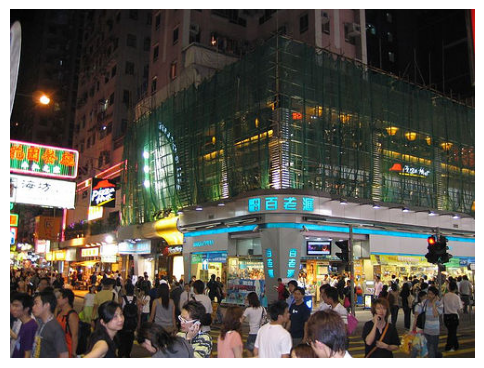

Filename: 26758039.jpg
Caption: A worker at a hotel pushing a cart full of luggage.
Ground truth: Negative pair
Frozen model: Positive (0.745)
Fine-tuned model: Positive (0.523)
Category: Both wrong
--------------------------------------------------------------------------------


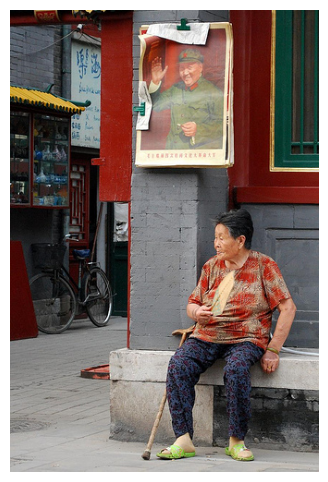

Filename: 3047788420.jpg
Caption: An elderly Asian woman wearing a straw-like hat sits outside near a bicycle while a gray car is about to pass by.
Ground truth: Negative pair
Frozen model: Positive (0.699)
Fine-tuned model: Positive (0.894)
Category: Both wrong
--------------------------------------------------------------------------------


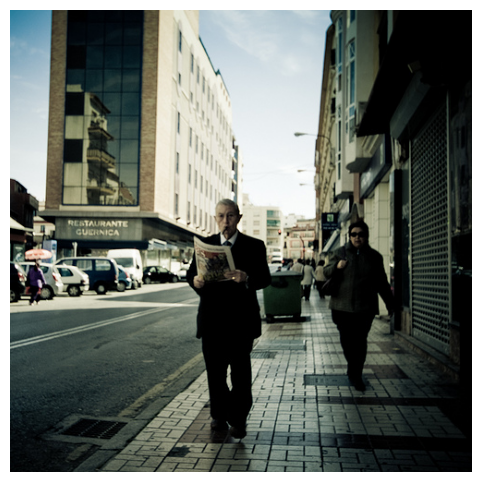

Filename: 4508496980.jpg
Caption: A man and woman are riding bikes on a street with a gray van visible in the background next to other cars.
Ground truth: Negative pair
Frozen model: Positive (0.741)
Fine-tuned model: Positive (0.893)
Category: Both wrong
--------------------------------------------------------------------------------


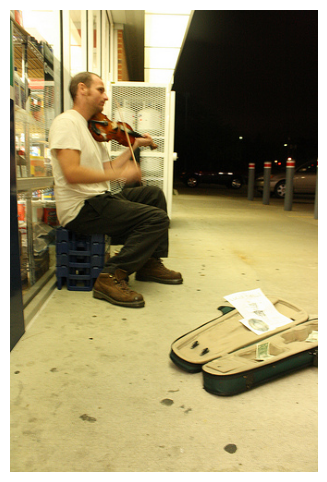

Filename: 4738994499.jpg
Caption: A man with green pants sitting with a tray on his lap.
Ground truth: Negative pair
Frozen model: Positive (0.771)
Fine-tuned model: Positive (0.740)
Category: Both wrong
--------------------------------------------------------------------------------


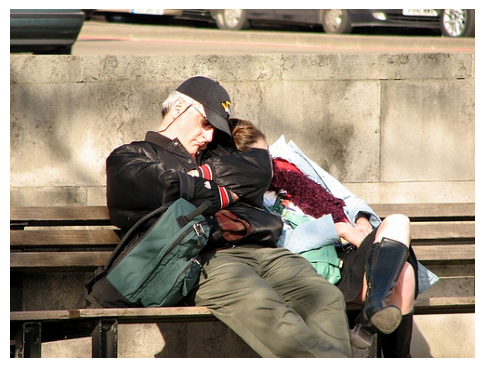

Filename: 599235529.jpg
Caption: A negro male in a white t-shirt and a black hat sitting on the curb texting.
Ground truth: Negative pair
Frozen model: Positive (0.674)
Fine-tuned model: Positive (0.507)
Category: Both wrong
--------------------------------------------------------------------------------


In [58]:
show_prediction_examples(
    dataframe=analysis_df,
    hf_dataset=val_data,
    category="Both wrong",
    n=10,
    random_state=RANDOM_SEED,
    title="Examples misclassified by both models",
)

### Observation

Most examples misclassified by both models are negative image-caption pairs with a high degree of semantic similarity. Although the captions do not correctly describe the corresponding images, they often share many visual concepts, such as the same people, objects, or scene type, differing only in specific actions, attributes, or relationships.

These examples demonstrate that the current models are effective at capturing general semantic correspondence but struggle to verify fine-grained details within the image-caption pair. As a result, both models assign high confidence to difficult negative examples that appear plausible at a coarse semantic level.

This analysis suggests that future improvements should focus on learning more discriminative multimodal representations and incorporating harder negative examples during training, rather than simply increasing model capacity.


## Summary

This notebook analyzed the behavior of the frozen and fine-tuned ResNet18 multimodal classifiers beyond standard evaluation metrics. By examining prediction agreement, threshold sensitivity, probability distributions, and representative prediction examples, the analysis provided a deeper understanding of the strengths and limitations of each model.

The frozen ResNet18 model achieved the highest F1-score by favoring positive predictions, resulting in very high recall but lower precision. In contrast, the fine-tuned model produced a more balanced decision boundary, improving precision and overall accuracy while sacrificing some recall.

The qualitative analysis revealed that the remaining errors are predominantly difficult negative image-caption pairs with high semantic similarity. Although the models successfully capture the general scene and objects, they often struggle to distinguish subtle differences in actions, attributes, and relationships. These findings suggest that future improvements should focus on learning richer multimodal representations and incorporating more challenging negative examples during training.
